# Practical session 4 - K-nearest neighbours (K-NN) classification with numpy, scikit-learn, cython and numba

Students (pair):
- [FERHOUN Zineb]([link](https://github.com/zineb-f))
- [AMALADASSE Louise]([link](https://github.com/louiseamaladasse-a11y))

**Useful references for this lab**:

[1] scikit-learn: [documentation](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification)

[2] `numba`: [documentation](http://numba.pydata.org/) 

[3] cython: [a very useful tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), and [another one](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html)



## <a name="content">Contents</a>
- [Exercise 1: KNN classification with numpy and sklearn](#ex1)
- [Exercise 2: Code acceleration with cython](#ex2)
- [Exercise 3: Code acceleration with numba](#ex3)
---

In [80]:
%load_ext autoreload
%autoreload 2

## <a name="ex1">Exercise 1: K-Nearest Neighbours (K-NN) classification with numpy and scikit-learn</a> [(&#8593;)](#content)

This session is a first introduction to classification using the most intuitive non parametric method: the $K$-nearest neighbours. The principle is [the following](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification). A set of labelled observations is given as a learning set. A classification taks then consists in assigning a label to any new observation. In particular, the K-NN approach consists in assigning to the observation the most frequent label among its $K$ nearest neighbours taken in the training set.

### A. Validation on synthetic data

Load the training and test datasets `data/synth_train.txt` and `data/synth_test.txt`. Targets belong to the set $\{1,2\}$ and entries belong to $\mathbb{R}^2$. The file `data/synth_train.txt` contain 100 training data samples, and `data/synth_test.txt` contains 200 test samples, where:

- the 1st column contains the label of the class the sample;
- columns 2 & 3 contain the coordinates of each sample (in $\mathbb{R}^2$).

Useful commands can be found below.

```python
# load the training set
train = np.loadtxt('data/synth_train.txt')  #...,delimiter=',') if there are ',' as delimiters
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]
```

```python
# load the test set
test = np.loadtxt('/datasynth_test.txt') 
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]
```

1\. Display the training set and distinguish the two classes. 

> Hint: useful functions include `matplotlib.pyplot.scatter` or `matplotlib.pyplot.plot`.

**Answer:**

In [83]:
import numpy as np

train = np.loadtxt('data/synth_train.txt')  #...,delimiter=',') if there are ',' as delimiters
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]

test = np.loadtxt('data/synth_test.txt')
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]

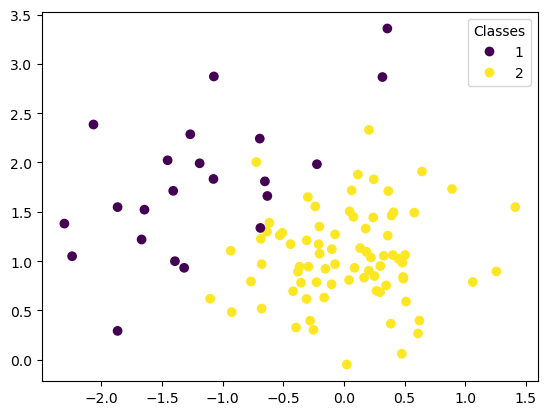

In [105]:
import matplotlib.pyplot as plt

scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=class_train)
plt.legend(*scatter.legend_elements(), title="Classes") #Légende des classes
plt.show()

2\. Implement the K-nearest neighbours algorithm for classification.

> Hint: 
> - useful functions include `numpy.linalg.norm`, `numpy.argsort`, `numpy.bincount`;
> - implement the algorithm as a function rather than an object. This will drastically simplify the acceleration step using Cython.
> - for an optimized partial sorting procedure, you may have a look at the [`bottleneck.argpartition` function](https://bottleneck.readthedocs.io/en/latest/reference.html#bottleneck.argpartition).

**Answer:**

In [ ]:
from fonctions import k_nn

x = [1,1]
k_nn(x, x_train, class_train, 10)

2

In [74]:
!pytest test_knn.py

============================= test session starts =============================
platform win32 -- Python 3.8.20, pytest-8.3.5, pluggy-1.5.0
rootdir: c:\Users\louis\Desktop\Centrale Lille\SDI\Python\python_sdia\Labs\Lab4
plugins: anyio-4.2.0
collected 2 items

test_knn.py ..                                                           [100%]

============================== 2 passed in 0.26s ==============================


3\. Compute the error rate on the training set and the test set for $K \in \{1,2, \dotsc, 20\}$. Display the classification result (see 1.) for the configuration with the lowest error rate.

**Answer:**

Erreur training set : [0.0, 0.03, 0.03, 0.03, 0.05, 0.03, 0.06, 0.06, 0.06, 0.06, 0.07, 0.07, 0.08, 0.07, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08]
Erreur test set : [0.065, 0.06, 0.045, 0.05, 0.06, 0.055, 0.07, 0.07, 0.075, 0.075, 0.09, 0.075, 0.08, 0.075, 0.075, 0.075, 0.08, 0.08, 0.08, 0.08]


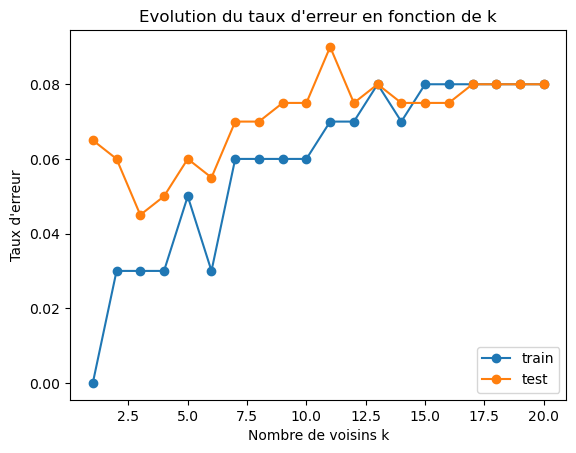

Le nombre de voisins optimal est : 3


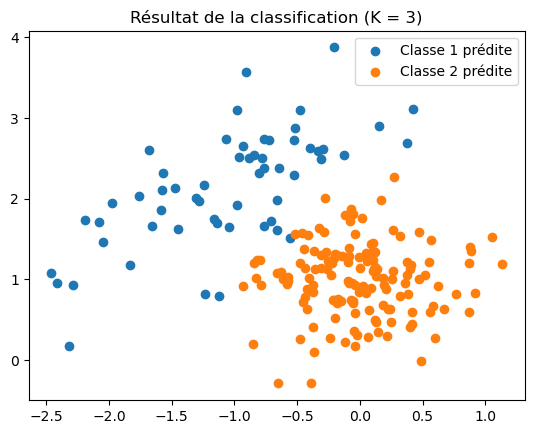

In [142]:
# Calcul du taux d'erreur en fonction du nombre de voisins
K = list(range(1,21))

errors_train = []
errors_test = []

for k in K :
    preds_train = np.array([k_nn(x, x_train, class_train, k) for x in x_train])
    error_train = np.mean(preds_train != class_train)
    errors_train.append(error_train)

    preds_test = np.array([k_nn(x, x_train, class_train, k) for x in x_test])
    error_test = np.mean(test[:,0] != preds_test)
    errors_test.append(error_test)

print(f"Erreur training set : {errors_train}")
print(f"Erreur test set : {errors_test}")

plt.plot(K, errors_train, marker = 'o', label = "train")
plt.plot(K, errors_test, marker = 'o', label = "test")
plt.xlabel("Nombre de voisins k")
plt.ylabel("Taux d'erreur")
plt.title("Evolution du taux d'erreur en fonction de k")
plt.legend(loc = "lower right")
plt.show()

# Résultat de classification pour le meilleur k
# On prend le k correspondant à l'indice qui a la plus petite erreur
best_k = K[np.argmin(errors_test)]
print(f"Le nombre de voisins optimal est : {best_k}")

pred = np.array([k_nn(x, x_train, class_train, best_k) for x in x_test])

plt.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], label="Classe 1 prédite")
plt.scatter(x_test[pred == 2, 0], x_test[pred == 2, 1], label="Classe 2 prédite")
plt.title(f"Résultat de la classification (K = {best_k})")
plt.legend()
plt.show()

4\. Comment on your results. Which value of $K$ seems optimal ?

**Answer:**

Pour K=1, on observe que sur le train set, l'erreur est optimale, elle vaut 0! C'est normal, le modèle apprend parfaitement les points du train, chaque point est son plus proche voisin, mais on voit tout de suite quand on prend le dataset de test, que l'erreur est bien plus élevée (~7%), on fait du sur-apprentissage. 
Pour des K trop élevés, la frontière de décision est trop lissée, on perd de l'information, on a une hausse des erreurs (d'apprentissage et de tets), on est dans une situation de sous-apprentissage. 
La valeur k = 3 est le meilleur compromis biais-variance, elle donne l'erreur la plus faible sur le set de test. 

5\. Compare the results of you implementation with those of [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?highlight=kneighborsclassifier#sklearn.neighbors.KNeighborsClassifier). Compare the runtime of these two versions using the [`timeit`](https://docs.python.org/3/library/timeit.html) module (see session 1).

**Answer:**

In [149]:
from sklearn.neighbors import KNeighborsClassifier

# Comparaison des résultats
KNN = KNeighborsClassifier(n_neighbors=3)
KNN.fit(x_train, class_train)
sklearn_pred = KNN.predict(x_test)
# On vérifie point par point si les prédictions de notre fonction sont les mêmes que celle de la fonction sklearn
print(f"Les prédictions sont-elles toutes les mêmes? {np.array_equal(sklearn_pred, pred)}.")

%timeit [k_nn(x, x_train, class_train, best_k) for x in x_test]
%timeit KNN.predict(x_test)

Les prédictions sont-elles toutes les mêmes? True.
9.72 ms ± 467 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
11.3 ms ± 64.2 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


On observe que notre fonction est plus rapide que celle de sickit-learn, en effet, sur le petit jeu de 200 données utilisé, sickit-learn, qui est adapté pour les gros dataset, est plus long.

### B. Application to a real dataset (Breast cancer Wisconsin).

6\. Apply the K-NN classifier to the real dataset `data/wdbc12.data.txt.` Further details about the data are provided in `data/wdbc12.names.txt`.

> Hint: you can use the function [`train_test_split` from `sklearn.model_selection`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to split the dataset into a training and a test set.

**Answer:**

### Préparation des données

In [214]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataset = np.loadtxt('data/wdbc12.data.txt', delimiter=",")

# D'après la documentation, la colonne 0 est l'ID du patient : attribut non pertinent pour la classification, la colonne 1 est le diagnostic donc notre classe et le reste sont les différents attributs
# On nous indique aussi qu'il ne manque aucune donnée, donc pas besoin de nettoyer les données au préalable

# On prépare les données :
X = dataset[:,2:]
label = dataset[:, 1] # Colonne 1

X_train, X_test, class_train, class_test = train_test_split(X, label, test_size=0.2,random_state=0, stratify = label)
# stratify = label permet de s'assurer qu'on conserve les proportions de classe dans les ensembles de train et de test (pas de déséquilibre)

# Etant donné que les attributs sont de natures très différentes (cf doc), et ont donc des ordres de grandeur très différents, on va normaliser les données avant de prédire
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Recherche du meilleur k

Erreur test set : [0.05263157894736842, 0.07894736842105263, 0.043859649122807015, 0.03508771929824561, 0.043859649122807015, 0.03508771929824561, 0.03508771929824561, 0.03508771929824561, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.05263157894736842, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.05263157894736842, 0.043859649122807015, 0.05263157894736842, 0.043859649122807015, 0.043859649122807015, 0.043859649122807015, 0.05263157894736842, 0.05263157894736842]


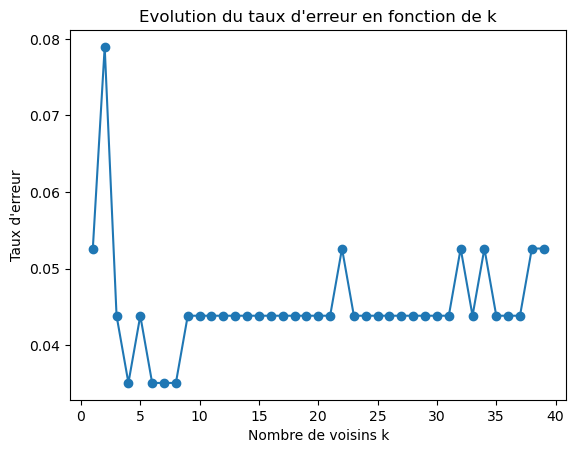

Le nombre de voisins optimal est : 4


In [215]:
K = list(range(1,40))

errors = []

for k in K :
    preds = np.array([k_nn(x, X_train_scaled, class_train, k) for x in X_test_scaled])
    error = np.mean(class_test != preds)
    errors.append(error)

print(f"Erreur test set : {errors}")

plt.plot(K, errors, marker = 'o')
plt.xlabel("Nombre de voisins k")
plt.ylabel("Taux d'erreur")
plt.title("Evolution du taux d'erreur en fonction de k")
plt.show()

best_k = K[np.argmin(errors)]
print(f"Le nombre de voisins optimal est : {best_k}")

4 est pair, ce n'est pas idéal pour une classification par k plus proches voisins, on va plutôt prendre 7 (impair et même taux d'erreur).

### Résultats de classification avec k optimal 

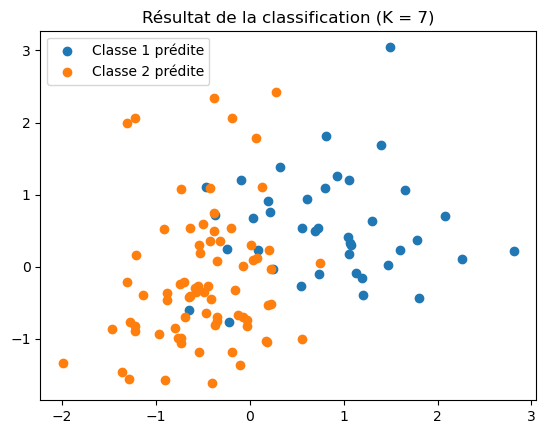

Matrice de confusion :
[[39  3]
 [ 1 71]]


In [216]:
pred = np.array([k_nn(x, X_train_scaled, class_train, 7) for x in X_test_scaled])

plt.scatter(X_test_scaled[pred == 1, 0], X_test_scaled[pred == 1, 1], label="Classe 1 prédite")
plt.scatter(X_test_scaled[pred == 2, 0], X_test_scaled[pred == 2, 1], label="Classe 2 prédite")
plt.title(f"Résultat de la classification (K = {7})")
plt.legend()
plt.show()


pred_manual = [k_nn(x, X_train_scaled, class_train, 7) for x in X_test_scaled]
np.array_equal(pred_manual, class_test)
np.sum([pred_manual!=class_test])
np.sum([pred_manual==class_test])

from sklearn.metrics import classification_report, confusion_matrix

print("Matrice de confusion :")
print(confusion_matrix(class_test, pred))

### Comparaison avec fonction sklearn

In [217]:
pred_manual = np.array([k_nn(x, X_train_scaled, class_train, 7) for x in X_test_scaled])

knn_sk = KNeighborsClassifier(n_neighbors=7)
knn_sk.fit(X_train_scaled, class_train)
pred_sk = knn_sk.predict(X_test_scaled)

print(f"Prédictions identiques à Sklearn pour K={7} ? {np.array_equal(pred_manual, pred_sk)}")

print("\n--- Temps d'exécution ---")
%timeit [k_nn(x, X_train_scaled, class_train, 7) for x in X_test_scaled]
%timeit knn_sk.predict(X_test_scaled)

Prédictions identiques à Sklearn pour K=7 ? True

--- Temps d'exécution ---
15.5 ms ± 247 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
11.7 ms ± 247 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Sur un exemple réel, on remarque que l'approche KNN est très satisfaisante, elle donne seulement 4 erreurs sur 114 individus (cf. matrice de confusion). Quand bien même les prédictions obtenues sont les mêmes avec notre fonction et avec celle de sklearn, on observe cette fois-ci que la fonction de sklearn est plus rapide (dataset à 30 dimensions).

## <a name="ex2">Exercise 2: Code acceleration with cython</a> [(&#8593;)](#content)

Cython allows C code to be easily interfaced with Python. It can be useful to make your code faster for a small coding effort, in particular when using loops. A general approach to optimize your code is outlined in the [Scipy lecture notes, Section 2.4](https://scipy-lectures.org/advanced/optimizing/index.html). Complementary reading about interfacing Python with C can be found in [Section 2.8](https://scipy-lectures.org/advanced/interfacing_with_c/interfacing_with_c.html).

1\. Read carefully the [cython tutorial](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html), which describes step by the step how the toy example reported below has been developed.

**Setup**: Compile the toy example provided in `example_cy/` by running, in the command line (anaconda prompt on windows)

```bash
cd example_cy && python setup.py build_ext --inplace
```

Note that the compilation process has been slightly automatised with the instructions reported in `example_cy/setup.py`. To test the module, run

In [209]:
!cd example_cy && python setup.py build_ext --inplace

Compiling helloworld.pyx because it changed.
Compiling primes.pyx because it changed.
[1/2] Cythonizing helloworld.pyx
[2/2] Cythonizing primes.pyx


error: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/


In [210]:
import example_cy.example_cy.helloworld as toy

toy.printhello()

ModuleNotFoundError: No module named 'example_cy.example_cy'

which should display
```python
Hello World
```

> Warning: 
> - do not forget to include an empty `__init__.py` file in the directory where your source code lives (`import` will fail if this is not the case).
> - in case you have any setup issue, take a look at the `notes.md` file.
> - if the C code and/or the executable do not seem to be regenerated by the build instructions, delete the C code and the executable first, and re-execute the compilation afterwards.
> - do not hesitate to restart the Python kernel if necessary when the Cython executable has been re-generated.

2\. Read the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), focussing on the paragraphs **Cython at a glance**, and **Your Cython environment** until **"More generic code"**. An example to compile a `.pyx` file depending on `numpy` is included in `example_np_cy/`.

> Remarks: 
> - the `annotate=True` flag in the `setup.py` allows an additional `.html` document to be generated (`<your_module_name>.html`), showing, for each line of the Cython code, the associated C instructions generated. Highlighted in yellow are the interactions with Python: the darker a region appears, the less efficient the generated C code is for this section. Work in priority on these! 
> - make sure all the previously generated files are deleted to allow the .html report to be generated;
> - if you are working on your own machine and don't have a C/C++ compiler installed, read the notes provided in `notes.md`;
> - use `cdef` for pure C functions (not exported to Python), `cpdef` should be favored for functions containing C instructions and later called from Python.

**Answer:**

In [ ]:
# your code

3\. Use Cython to implement a faster version of the numpy K-NN classifier implemented in [Exercise 1](#ex1). To do so, apply step-by-step the techniques introduced in the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial) (*i.e.*, compile and time your code after each step to report the evolution, keeping track of the different versions of the cython function).

> Hint: if you keep numpy arrays, make sure you use memory views (see numpy/cython tutorial) to access the elements within it. Be extremely careful with the type of the input arrays (you may need to recast the format of the input elements before entering the function. The `numpy.asarray` function can prove useful).

> **Detailed guidelines**: a few notes and *caveat* to help you re-writing your code in cython:
> - try to reduce the number of calls to numpy instructions as much as possible;
> - **you do not have to optimize everything**. For the KNN function above, most of the time is spent in computing euclidean distances: you can thus focus on optimizing tihs operations by explicitly writing a for loop, which will ensure a minimal interaction with numpy when generating the associated C code at compilation. Calls to other numpy functions can be kept as-is;
> - if you need to create an array within the cython function, used np.zeros (**do NOT use python lists**), and use a memory view to access its content;
> - specify the type for all variables and numpy arrays. Pay attention to the type of the input arrays passed to the Cython function;
> - whenever an array is returned, use memory views and index(es) to efficiently access its content;
> - some numpy operators (e.g., broadcasting mechanism) do not work with memory views. In this case, you can directly write for loop(s) to encode the operation of interest (the loops will be optimized out at compile time);
> - only use at the final development stage the following cython optimization (not before, as they can crash the program without any help):
>
>```python
>@cython.boundscheck(False)
>@cython.wraparound(False)
>```

**Answer:**

In [ ]:
# your code

4\. Compare the runtime of the two algorithms (using `timeit.timeit`), and conclude about the interest of using cython in this case.

**Answer:**

In [ ]:
# your code

## <a name="ex3">Exercise 3: Code acceleration with numba</a> [(&#8593;)](#content)

`numba` is a just-in-time (JIT) compiler which translates Python codes into efficient machine code at runtime. A significant acceleration can be obtained by adding a few simple decorators to a standard Python function, up to a few restrictions detailed [here](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html).

If you have written most of the KNN classifier of exercise 1 with numpy, there is little to no chance that you will get an acceleration with numba (justifying the use of cython in this case). An interesting acceleration factor can however be obtained for the computation of the total variation investigated in session 2.

1\. Take a look at the [numba 5 min tour](http://numba.pydata.org/numba-doc/latest/user/5minguide.html), and accelerate the total variation code from session 2 with the `@jit` decorator. You may have to rewrite small portions of your code to get the expected acceleration (see [performance tips](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html)).

**Answer:**

In [ ]:
# your code

2\. Compare the runtime of the your numpy implementation and the `numba`-accelerated version (using `timeit.timeit`). 
> **Warning**: first run the numba version once to trigger the compilation, and then time it as usual. This is needed to avoid including the JIT compilation step in the runtime.

**Answer:**

In [ ]:
# your code